In [3]:
import pandas as pd

df = pd.read_csv("tp_parseable.csv")

# fig 1: no short

In [7]:
# filter and add dummy value for cohere hybrid
IGNORED = ("claude", "mistral")
filtered = df[(~df["family"].isin(IGNORED)) & (~df["system"].str.contains("short"))]

# sort
family_order = ["cohere-hf", "qwen3", "gpt-oss", "openai", "glm"]
system_order = ["small-baseline", "small-all", "small-leaf", "baseline", "root-fc", "full"]
filtered = filtered.sort_values(by=["family", "system"], key=lambda col: col.map((family_order + system_order).index))
# filtered

# rename
filtered['system'] = filtered['system'].replace(
    {"small-baseline": "Small (Baseline)", "small-all": "Small (ReDel)", "small-leaf": "Hybrid (ReDel)",
     "baseline": "Big (Baseline)", "root-fc": "Big (ReDel)", "full": "Big (Forced)"})
filtered['family'] = filtered['family'].replace(
    {"cohere-hf": "Command-R", "qwen3": "Qwen 3", "gpt-oss": "GPT-OSS", "openai": "OpenAI", "glm": "GLM"})

In [8]:
# filtered.to_csv("foqa_scores.csv")
# filtered

,family,system,delivery rate,cs micro,cs macro,hard micro,hard macro,hard micro fix,hard macro fix,final
13,Command-R,Small (Baseline),97.222,60.556,1.667,1.905,1.667,NaN,NaN,0.000
12,Command-R,Small (ReDel),53.889,30.764,0.556,0.952,1.111,NaN,NaN,0.556
11,Command-R,Hybrid (ReDel),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,Command-R,Big (Baseline),93.333,65.069,5.556,5.476,2.778,NaN,NaN,0.556
9,Command-R,Big (ReDel),92.778,64.931,3.333,7.619,2.222,NaN,NaN,0.000
8,Command-R,Big (Forced),84.444,52.153,1.111,1.190,1.111,NaN,NaN,0.000
37,Qwen 3,Small (Baseline),100.000,56.597,0.000,5.476,3.333,NaN,NaN,0.000
36,Qwen 3,Small (ReDel),100.000,55.764,0.000,0.000,0.000,NaN,NaN,0.000
35,Qwen 3,Hybrid (ReDel),100.000,63.056,0.000,0.000,0.000,NaN,NaN,0.000
34,Qwen 3,Big (Baseline),100.000,58.958,1.111,15.238,6.111,NaN,NaN,0.556


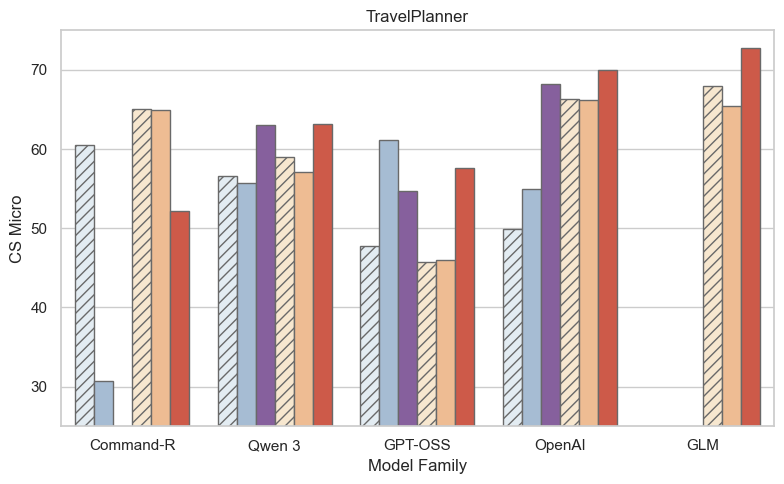

In [19]:
from matplotlib import pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the figure size (width, height)
plt.figure(figsize=(8, 5))

# Create the grouped bar chart
# https://colorbrewer2.org/#type=sequential&scheme=BuPu&n=6
colors = ["#e0ecf4", "#9ebcda", "#8856a7", "#fee8c8", "#fdbb84", "#e34a33"]
chart = sns.barplot(
    data=filtered,
    x='family',
    y='cs micro',
    hue='system',
    palette=sns.color_palette(colors),
)

# --- Hatching Logic ---
# Get the handles and labels to identify which container corresponds to 'baseline'
# 1. Get the current handles and labels for the legend
#    (These represent the 'hue' categories: small-all, full, etc.)
handles, labels = chart.get_legend_handles_labels()

# 2. Iterate through the labels to find which indices correspond to any "baseline" setting
baseline_indices = [i for i, label in enumerate(labels) if "baseline" in label.lower()]

# Iterate over the containers (each container represents one hue/setting group)
for i, container in enumerate(chart.containers):
    # Ensure we don't exceed the labels list
    for bar in container:
        if i in baseline_indices:
            # Apply the hatch pattern
            bar.set_hatch('///')
        bar.set_edgecolor('dimgray')
        bar.set_linewidth(1)
for i, handle in enumerate(handles):
    if i in baseline_indices:
        # Apply the hatch pattern
        handle.set_hatch('///')
    handle.set_edgecolor('dimgray')
    handle.set_linewidth(1)

# Add labels and title
plt.xlabel('Model Family')
plt.ylabel('CS Micro')

# Rotate x-axis labels for better readability
# plt.xticks(rotation=45)
plt.ylim(25, 75)

plt.title("TravelPlanner")
plt.legend('', frameon=False)

plt.tight_layout()
plt.savefig('img/tp_grouped.pdf')
plt.show()